# Análisis de los datos

In [1]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Se presenta un análisis detallado de las variables regresoras que serán empleadas para el modelo que predice el FRP de un incendio dada una latitud y longitud, así como las correlaciones entre ellas y con la variable objetivo

### **Caracteristicas de las variables**

In [2]:
# l_f = []
# for k in [2022, 2023,2024, 2025]:
#     print(f"Analizando el año {k}:")
#     dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/Modelo_Incendios_{k}.parquet", type="df")
#     l_f.append(dataf)
# dataFrame = pd.concat(l_f, ignore_index=True)

dataFrame = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/MI.parquet", type="df")

Dataframe importado correctamente


In [6]:
df_final = dataFrame.copy()

**COMPOSICIÓN DEL DATASET**

Las variables son:

In [7]:
print(f"Variables: {df_final.columns}")

Variables: Index(['lat', 'lon', 'frp_mean', 'date', 'area_ha', 'elevacion_centro',
       'grados', 'porcentaje', 'temp_mean', 'temp_max', 'temp_min',
       'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max',
       'pressure_mean', 'cloud_cover', 'radiation', 'evapotranspiration',
       'sunshine_seconds', 'NDVI', 'NDWI', 'dist_civ'],
      dtype='str')


Total de incendios:

In [8]:
print(f"Total: {len(df_final)} incendios")

Total: 2026 incendios


Representación primeras filas del dataset:

In [9]:
print(df_final.head(10))

         lat        lon    frp_mean       date   area_ha  elevacion_centro  \
0  43.219070  -6.655960  146.240000 2022-01-01     14.06       1012.903931   
1  36.876417   6.951603   65.496667 2022-01-04    124.22          4.535087   
2  45.191311  29.577375  101.732000 2022-01-05   2828.39          0.505476   
3  37.850200  22.449520   63.520000 2022-01-06     14.06        604.561340   
4  41.642350  -6.436230   72.490000 2022-01-15     14.06        721.111511   
5  44.986833  29.564723   82.397333 2022-01-21   3893.85          0.340551   
6  44.165150   3.618980   63.350000 2022-01-26     14.06        956.908752   
7  42.237090  -6.222850   55.420000 2022-01-26     14.06       1208.549438   
8  40.413691  -7.480300  158.089147 2022-01-27  28599.35        743.457153   
9  41.966776  -6.833300   95.647941 2022-01-28   2608.91       1123.853516   

      grados  porcentaje  temp_mean  temp_max  ...  wind_speed_max  \
0  28.050967   53.285100       11.5      14.6  ...            17.9   
1

**VARIABLE OBJETIVO**

La varible objetivo es una variable numérica continua. 

Esta variable es el frp_mean, y representa la potencia radiactiva del fuego, medida como la energía liberada por unidad de tiempo (MW)

In [10]:
print(df_final['frp_mean'])

0       146.240000
1        65.496667
2       101.732000
3        63.520000
4        72.490000
           ...    
2021     72.216667
2022     63.700000
2023     56.440000
2024    114.770000
2025     80.790000
Name: frp_mean, Length: 2026, dtype: float64


**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Eliminamos latitud y longitud, ya que se hizo un análisis en el notebook para el problema 1, en el que se observan las zonas de incendio.

Además, estas variables no serán empleadas en el modelo.

In [11]:
df = df_final.drop(columns = ['lat', 'lon'])
df.describe()

,frp_mean,date,area_ha,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,...,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ
count,2026.000000,2026,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,...,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,88.459182,2024-01-16 04:59:56.446199,534.149526,424.696476,8.058098,14.643384,21.556614,27.980207,15.408144,48.776900,...,18.547532,41.595953,968.473741,21.142646,23.021392,5.638332,43948.547206,0.404280,-0.439046,28.493077
min,50.090000,2022-01-01 00:00:00,11.030000,-4.045881,0.001912,0.003337,-4.600000,-0.400000,-9.100000,9.000000,...,3.700000,14.000000,718.400000,0.000000,3.560000,0.440000,0.000000,-0.335687,-0.844250,0.073528
25%,61.302500,2022-08-17 00:00:00,14.060000,113.903854,1.230652,2.148224,16.600000,22.500000,10.600000,38.000000,...,13.900000,32.400000,944.025000,1.000000,19.817500,4.000000,40466.437500,0.230289,-0.562344,3.555425
50%,76.353684,2024-03-10 00:00:00,28.120000,276.835129,5.297527,9.272366,24.100000,30.200000,17.700000,48.000000,...,17.800000,40.000000,982.700000,12.000000,24.655000,5.890000,45965.980000,0.379981,-0.435744,6.487014
75%,102.570000,2025-05-17 12:00:00,115.970000,634.575027,12.699013,22.534169,27.900000,34.500000,21.400000,59.000000,...,22.400000,48.600000,1001.775000,34.000000,27.460000,7.170000,48098.370000,0.567330,-0.337249,11.491541
max,607.340000,2025-12-29 00:00:00,75446.430000,2908.075684,58.684683,164.372099,39.000000,48.000000,33.500000,93.000000,...,47.900000,106.200000,1039.000000,100.000000,31.270000,12.360000,68808.280000,0.901769,1.000000,483.097458
std,41.699364,NaN,3335.599916,410.182645,8.327092,15.910742,8.657134,9.170685,8.226566,14.978918,...,6.501442,13.168684,44.854258,23.601923,5.554719,2.232889,6383.571473,0.212321,0.171239,75.399202


**DISTRIBUCIÓN DE LAS VARIABLES**

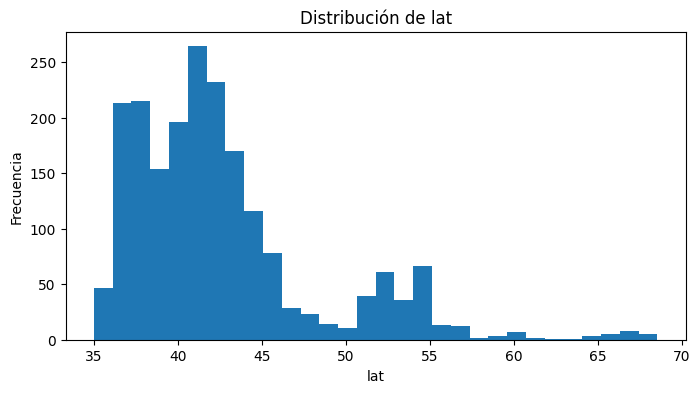

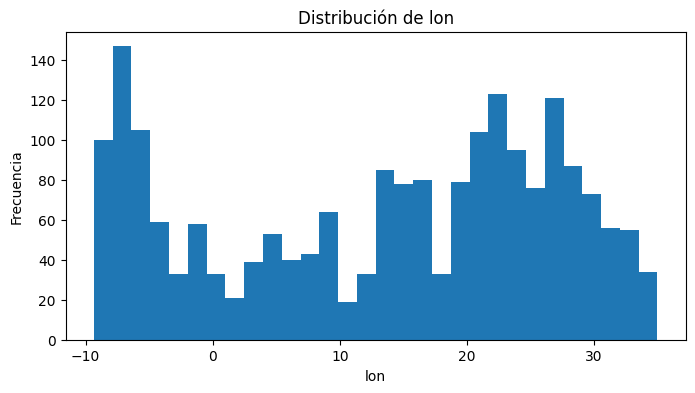

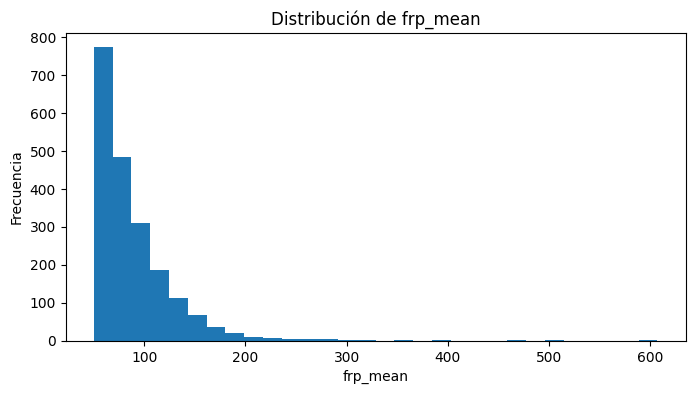

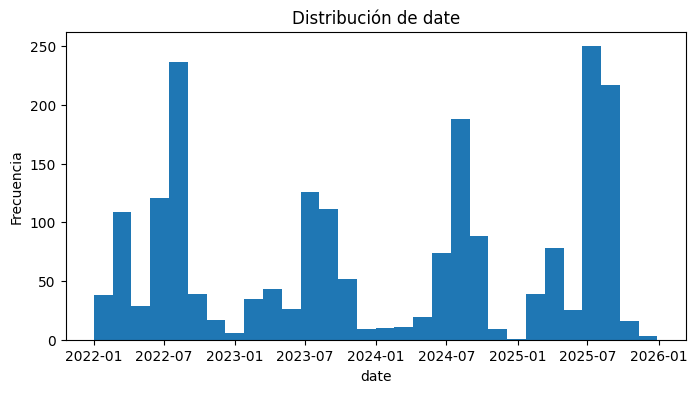

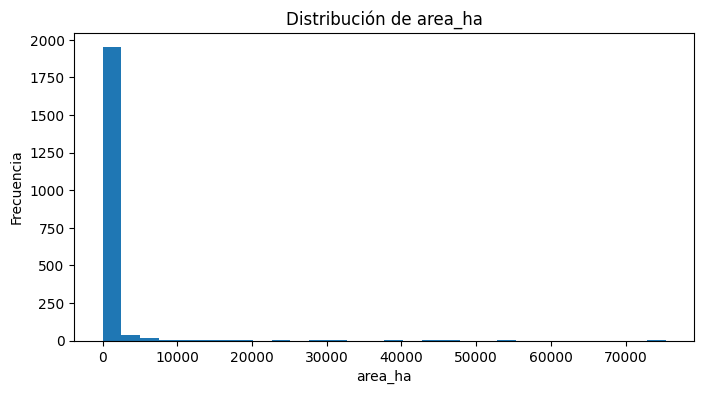

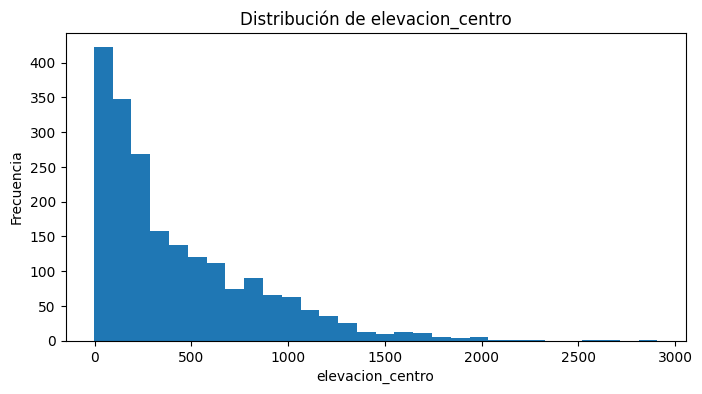

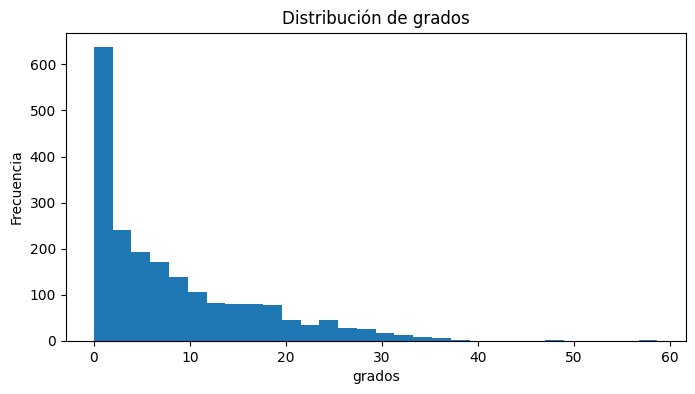

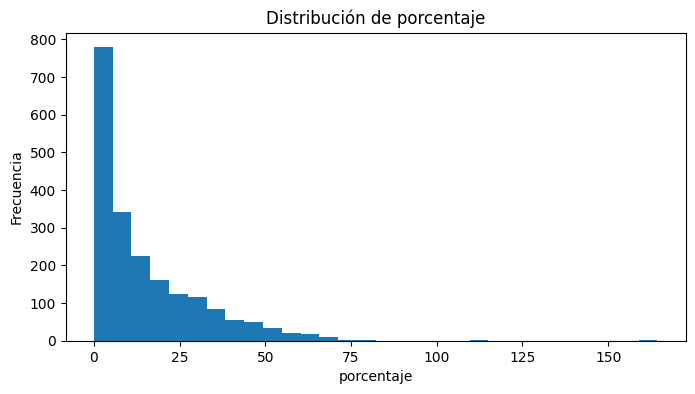

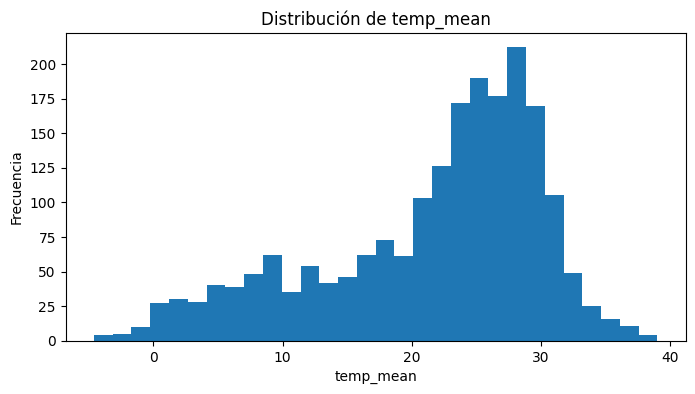

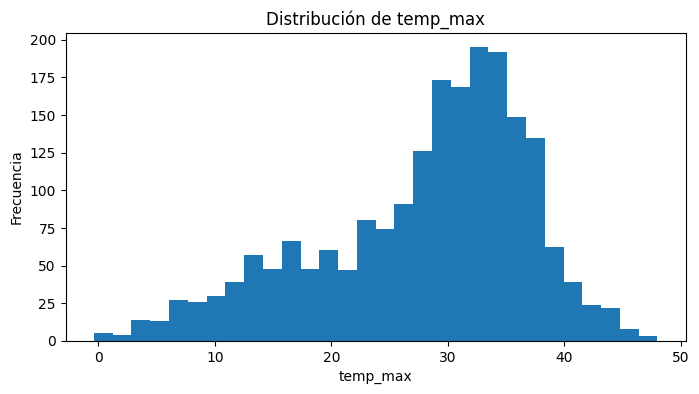

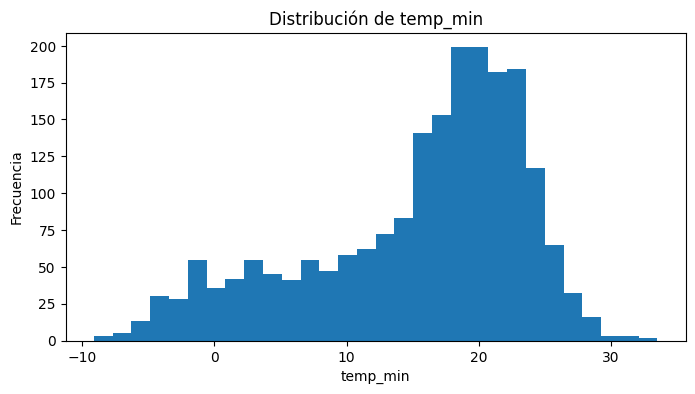

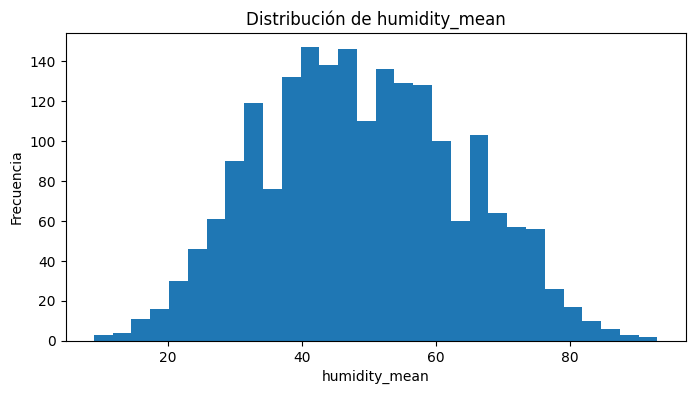

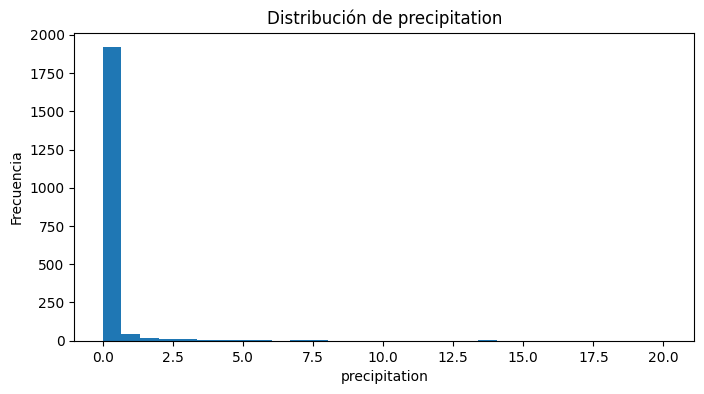

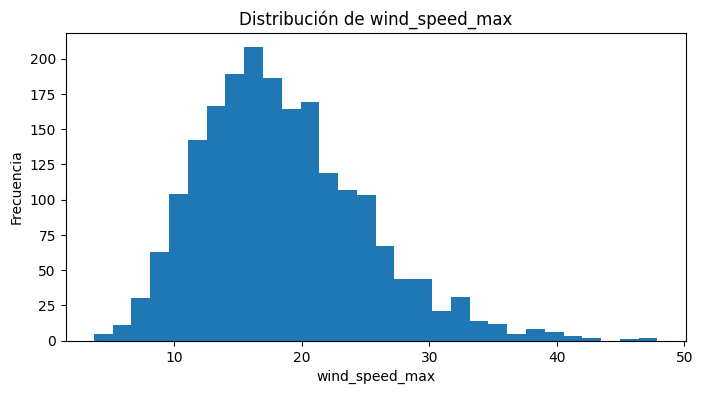

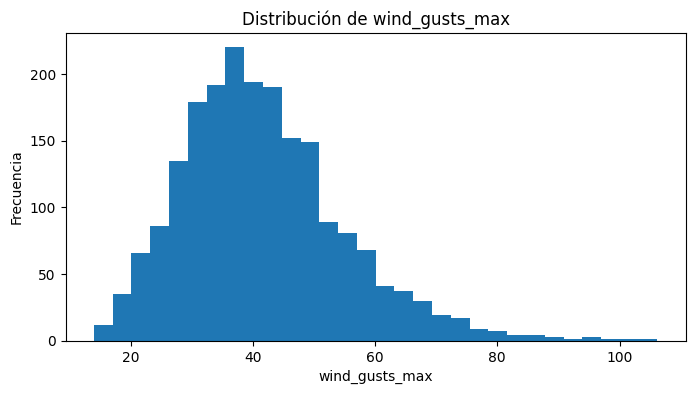

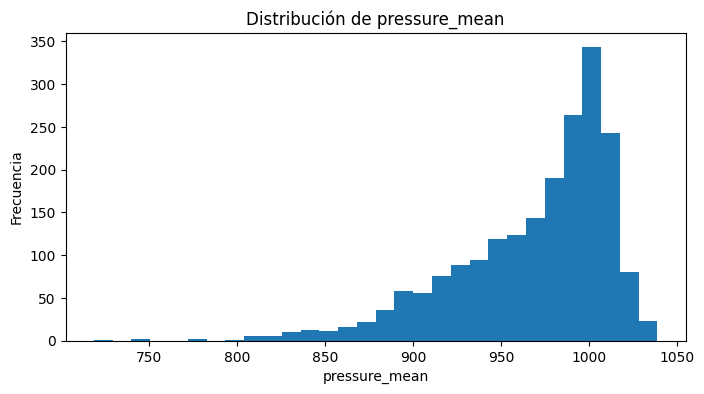

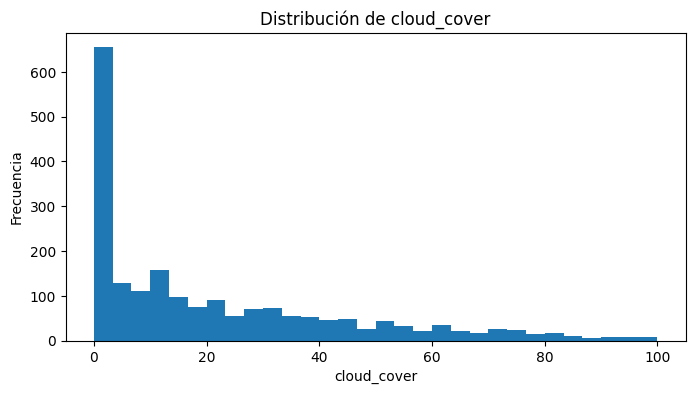

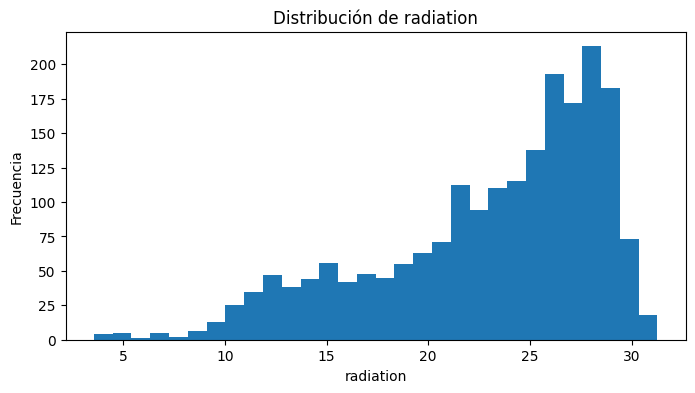

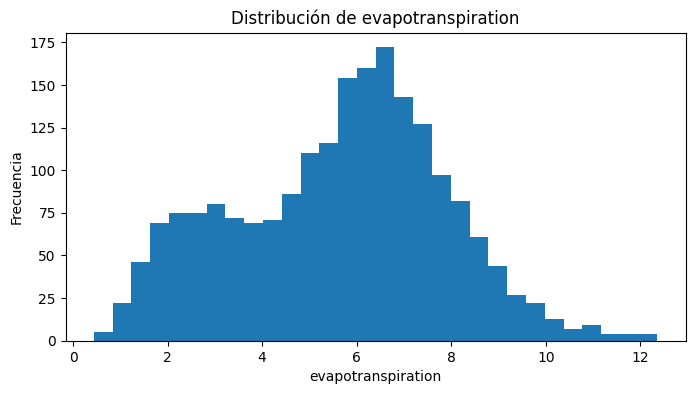

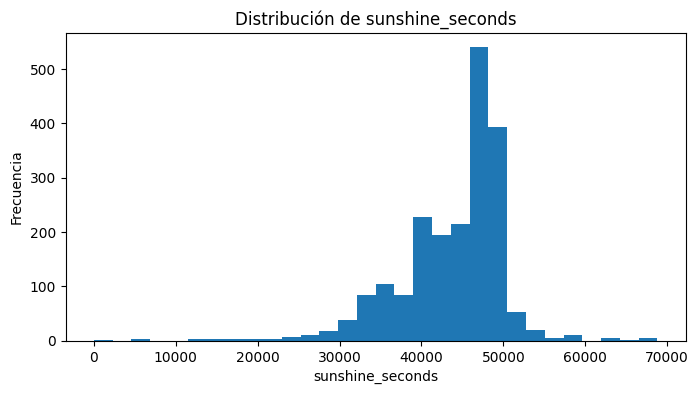

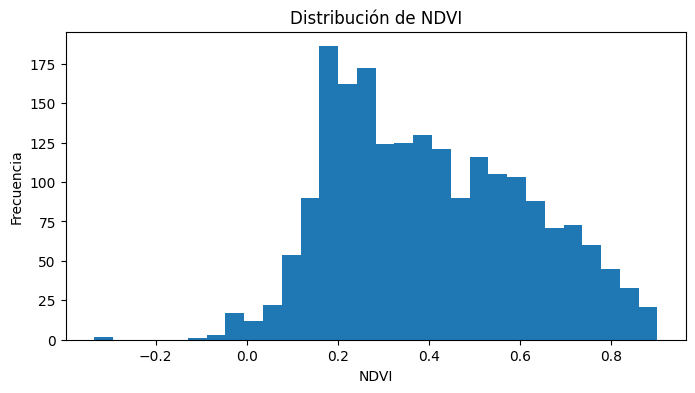

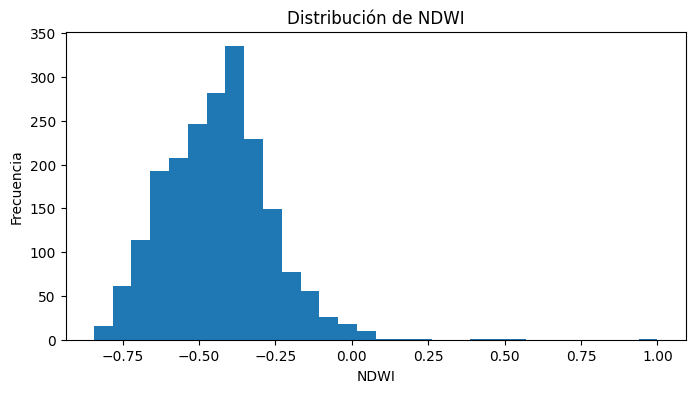

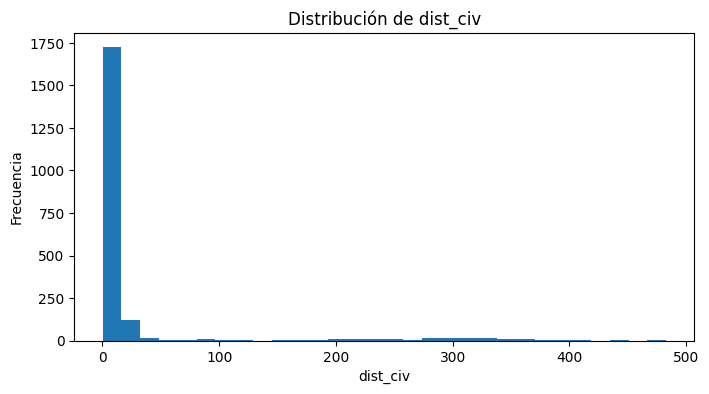

In [12]:
for col in df_final.columns:
    plt.figure(figsize=(8, 4))
    df_final[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

Se observa que la variable objetivo tiene muchas observaciones con valores altos, y solo algunas con valores bajos. 

Se debe tener en cuenta porque hay modelos que no son robustos a la presencia de outliers.

**ANÁLISIS DE LA PRESENCIA DE OUTLIERS**

Solo se realiza el estudio de outliers para hectáreas y frp porque para el resto de variables fue realizado en el notebook del problema 1.

In [13]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in ['frp_mean', 'area_ha']:
    outliers, limite_inf, limite_sup = detectar_outliers(df_final, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable frp_mean: Detectados 87 outliers (fuera del rango -0.60 - 164.47) 

Variable area_ha: Detectados 281 outliers (fuera del rango -138.81 - 268.84) 



Hacemos un análisis de dónde tenemos esos outliers. Para ello usaremos el df general, para poder dibujar el mapa de Europa:

In [15]:
dataFrame_general = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/MINI.parquet", type="df")

Dataframe importado correctamente


**1. Outliers en area_ha:**

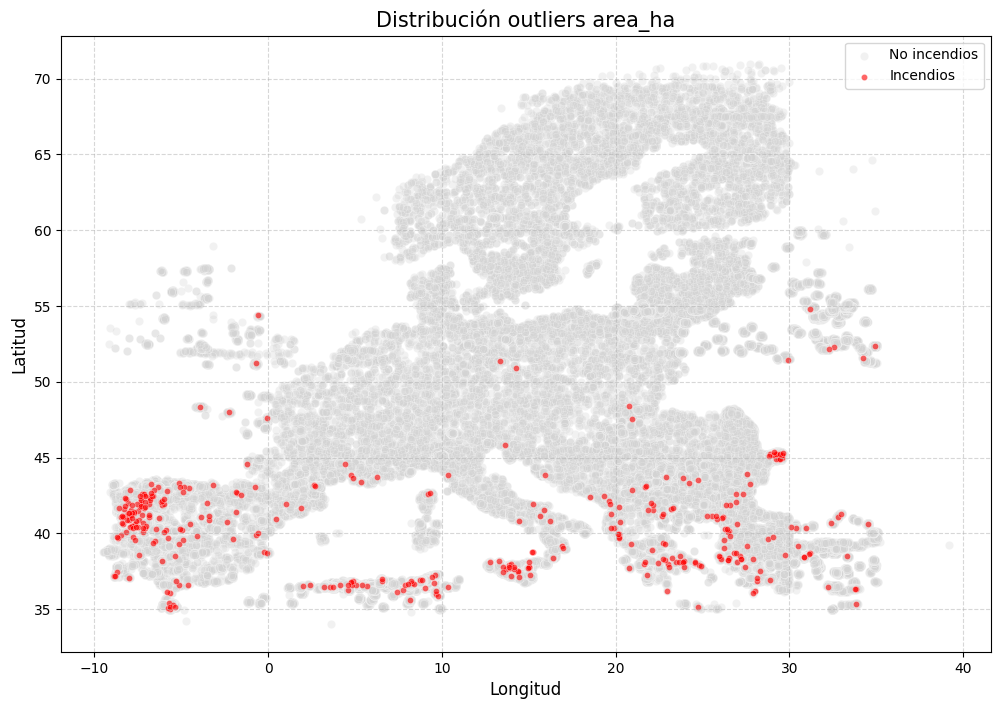

In [16]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['area_ha'] > 187.38]
datos_no_inc = dataFrame_general[dataFrame_general['final'] == 0]

sns.scatterplot(data=datos_no_inc, x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_dist, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución outliers area_ha', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**2. Outliers en frp_mean (variable objetivo):**

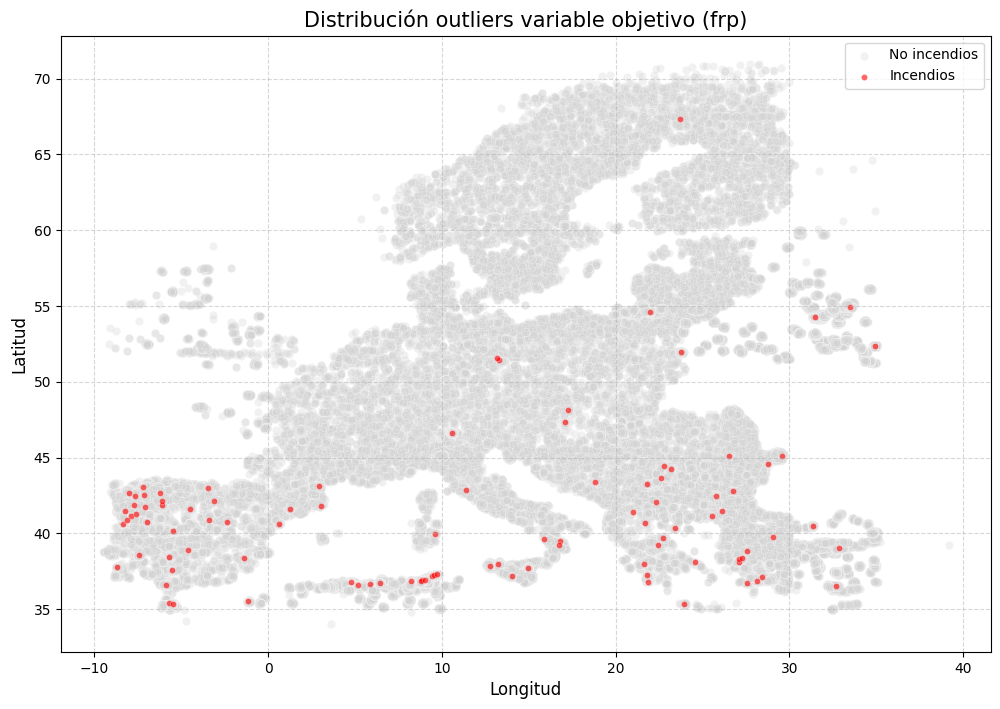

In [17]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['frp_mean'] > 160.09]
datos_no_inc = dataFrame_general[dataFrame_general['final'] == 0]

sns.scatterplot(data=datos_no_inc, x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_dist, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución outliers variable objetivo (frp)', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Los outliers detectados son completamente normales. La mayoría se encuentran en las zonas de Galicia y norte de Portugal, así como en Sicilia y el norte de África. Propios de la región Mediterránea y Estépica.

**CORRELACIONES ENTRE LAS VARIABLES REGRESORAS**

Posteriormente, se realizará un análisis de las correlaciones con la variable objetivo.

In [22]:
df2 = df_final.drop(columns = ['frp_mean', 'date'])
df2.corr().style.background_gradient(cmap='coolwarm')

,lat,lon,area_ha,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ
lat,1.000000,0.237331,-0.045065,-0.294617,-0.331200,-0.315383,-0.478661,-0.478282,-0.496580,0.395215,0.073097,-0.153255,-0.275584,0.328409,0.293083,-0.318587,-0.451694,0.008805,-0.106543,0.148973,-0.283617
lon,0.237331,1.000000,-0.103371,-0.240097,-0.248058,-0.238809,-0.146871,-0.161474,-0.140041,0.122658,-0.007770,-0.034838,-0.106503,0.232973,-0.077596,-0.153483,-0.155763,-0.043165,-0.165355,0.130526,-0.132457
area_ha,-0.045065,-0.103371,1.000000,0.095108,0.077362,0.074619,0.039960,0.037394,0.045701,-0.075083,-0.003006,0.056147,0.085913,-0.093046,-0.009523,0.025225,0.065880,0.004215,0.083305,-0.078332,-0.012744
elevacion_centro,-0.294617,-0.240097,0.095108,1.000000,0.463045,0.451601,-0.060959,-0.039774,-0.080963,-0.198891,0.006111,-0.239367,0.024423,-0.991267,-0.030458,0.060126,-0.021805,-0.040972,0.141732,-0.123673,0.120478
grados,-0.331200,-0.248058,0.077362,0.463045,1.000000,0.995707,0.130848,0.120523,0.149778,-0.147707,0.003733,-0.063164,0.207226,-0.482097,-0.064321,0.117483,0.112436,0.010831,0.316822,-0.248251,0.168376
porcentaje,-0.315383,-0.238809,0.074619,0.451601,0.995707,1.000000,0.121636,0.110752,0.140662,-0.138171,0.006408,-0.065349,0.199443,-0.470398,-0.060175,0.111067,0.103296,0.010134,0.303742,-0.235576,0.160240
temp_mean,-0.478661,-0.146871,0.039960,-0.060959,0.130848,0.121636,1.000000,0.983870,0.977800,-0.606336,-0.045080,0.199552,0.233619,-0.004858,-0.266910,0.732751,0.889584,0.586579,0.268617,-0.316848,0.202544
temp_max,-0.478282,-0.161474,0.037394,-0.039774,0.120523,0.110752,0.983870,1.000000,0.934268,-0.633075,-0.068002,0.151738,0.184076,-0.022947,-0.287588,0.722892,0.880339,0.575061,0.264653,-0.315027,0.232790
temp_min,-0.496580,-0.140041,0.045701,-0.080963,0.149778,0.140662,0.977800,0.934268,1.000000,-0.539213,-0.010822,0.264503,0.302672,0.013806,-0.230944,0.685808,0.858364,0.537281,0.266934,-0.311763,0.184422
humidity_mean,0.395215,0.122658,-0.075083,-0.198891,-0.147707,-0.138171,-0.606336,-0.633075,-0.539213,1.000000,0.202548,-0.136677,-0.204363,0.223452,0.330253,-0.532251,-0.737765,-0.371664,-0.137935,0.156192,-0.224819


<Axes: >

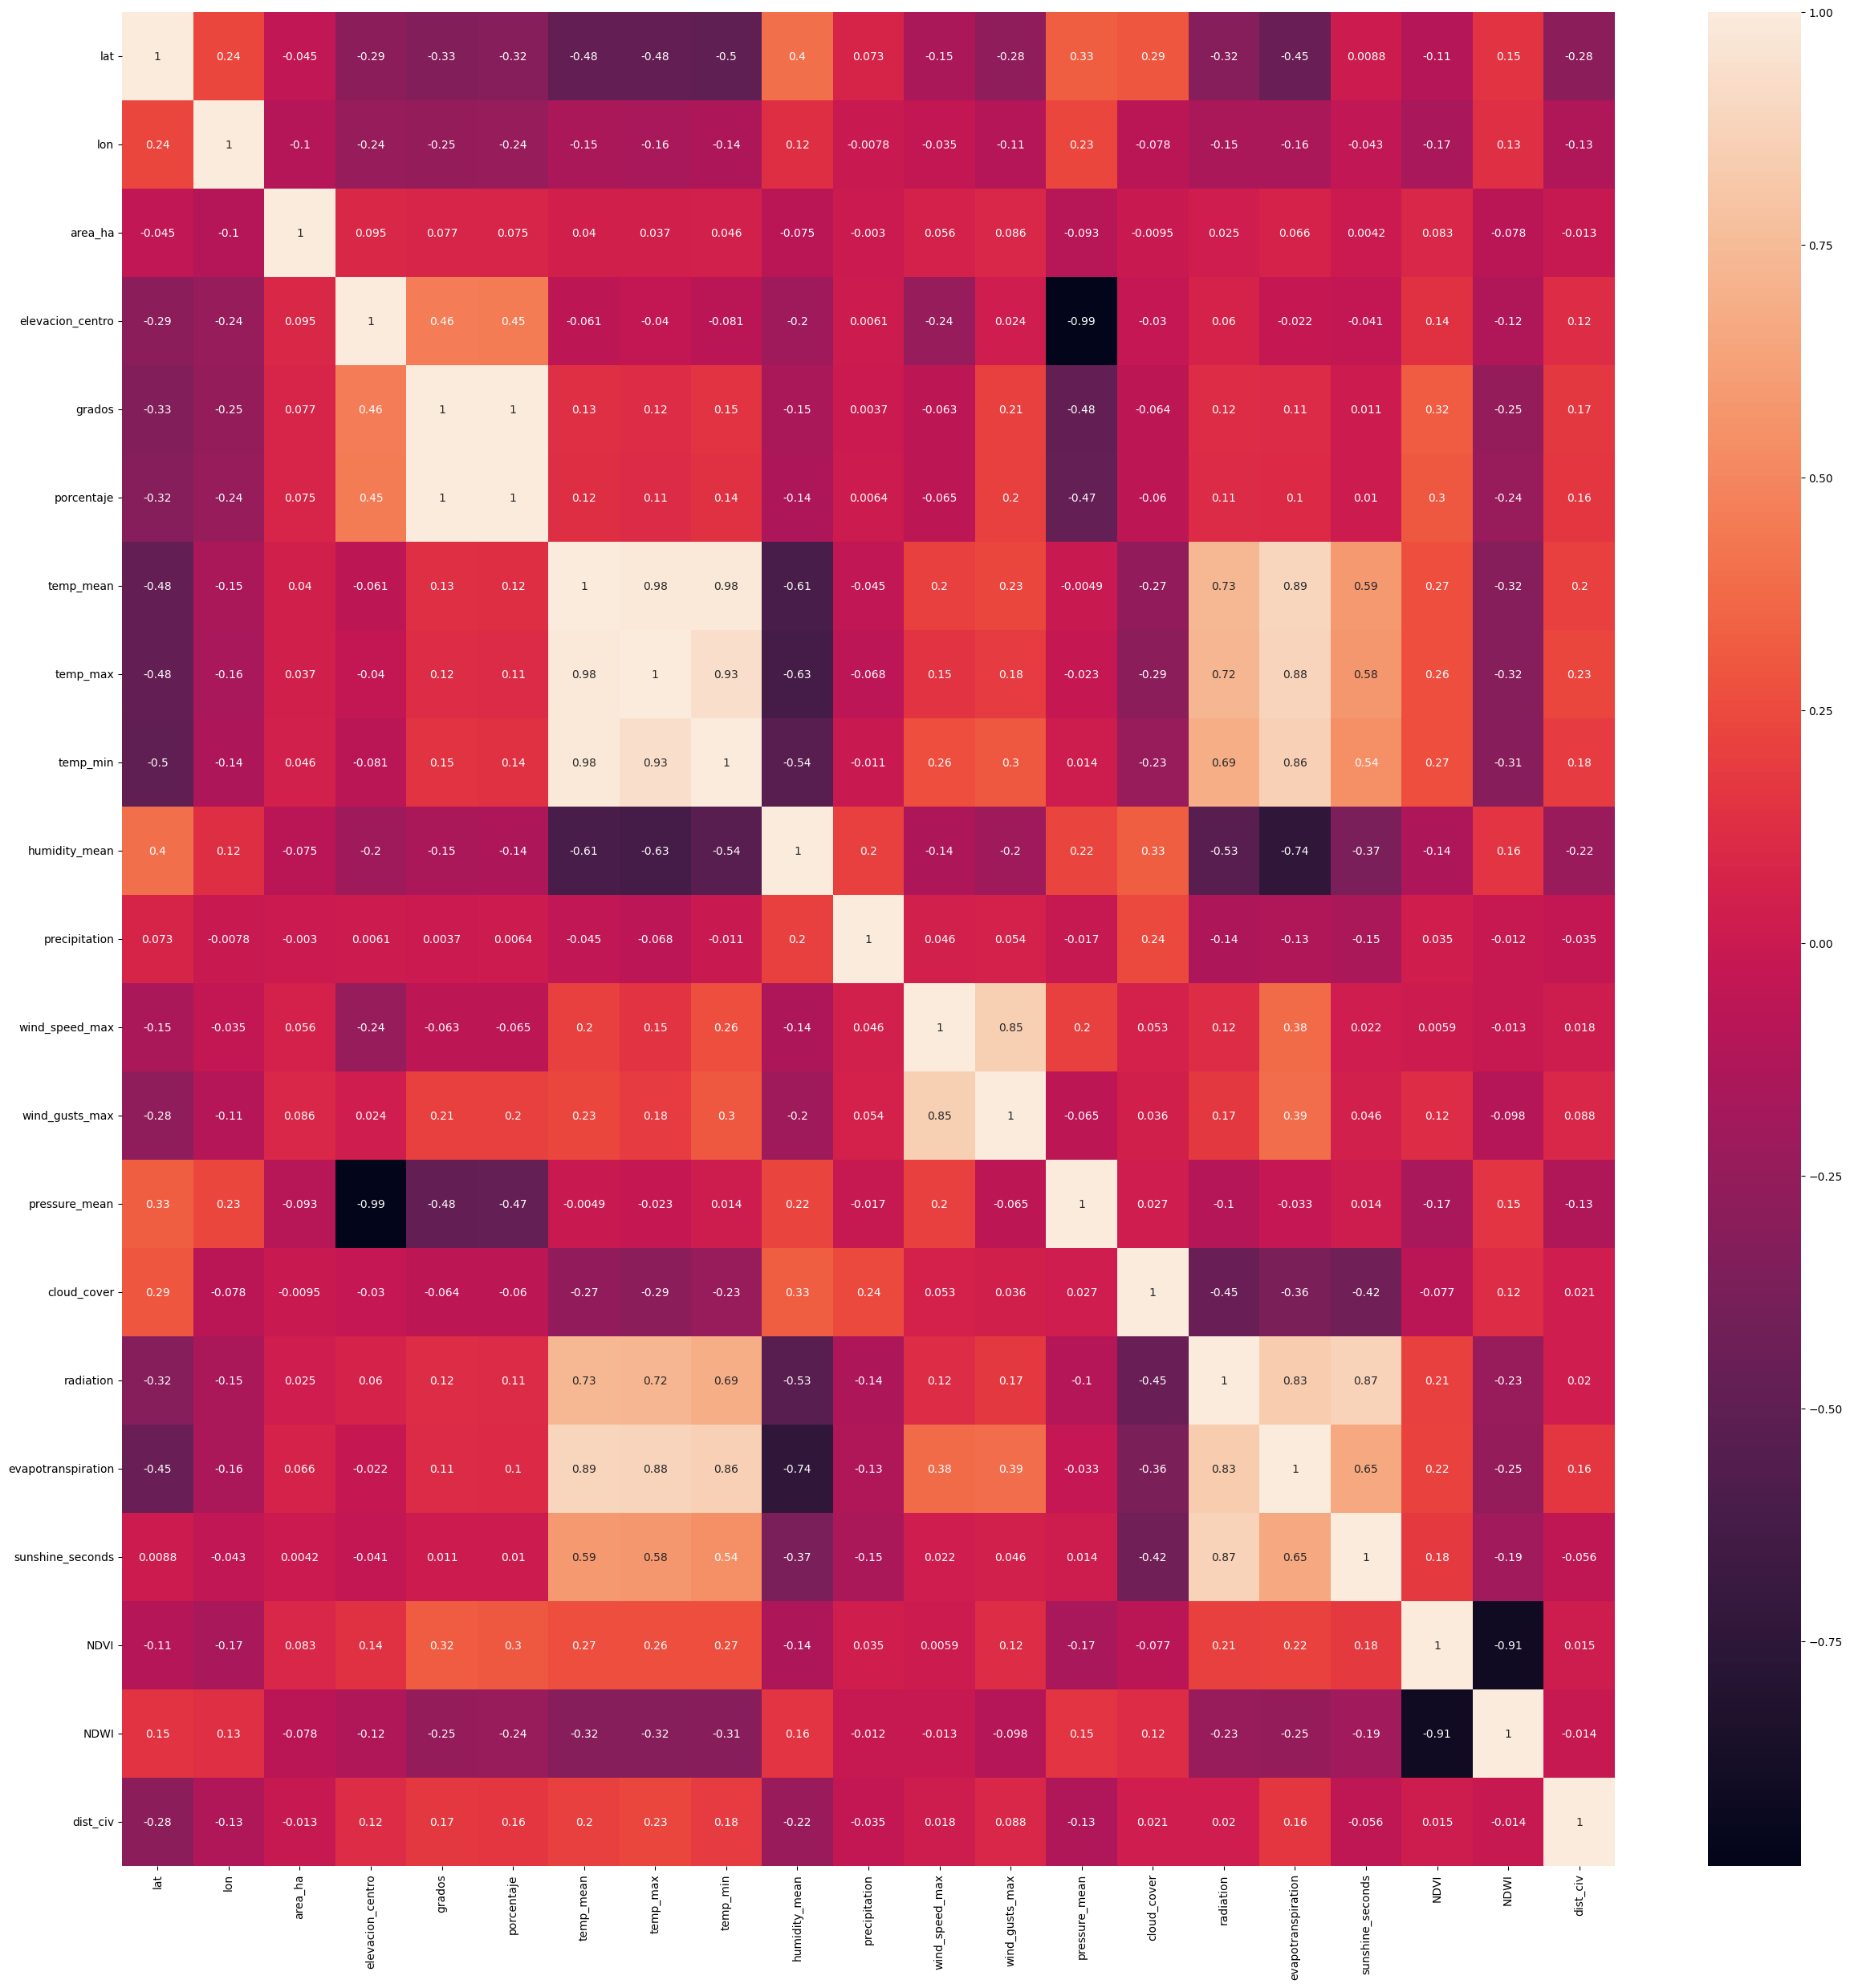

In [23]:
plt.figure(figsize=(30, 30))
sns.heatmap(df2.corr(), annot=True)

**Conclusiones:**

Las correlaciones han cambiado ligeramente con respecto al análisis realizado para el problema uno. Esto se debe a que el tamaño del dataset es menor, por lo que las correlaciones entre variables no se capturan completamente.

Aún así, se observa que hay muchas variables correlacionadas. Destacan:
1. **grados y porcentaje**, con una **correlación de 1**.
2. Las variables que representan la temperatura (**temp_max, temp_min y temp_mean**), con una correlación casi **cercana a 1**.
3. **pressure_mean y elevacion_centro**, con correlación negativa (**-0.99**).
4. **NDVI y NDWI**, con correlación negativa (valor **-0.91**).
5. La correlación de **evapotranspiration y radiation** (con valor **0.83**).
6. La correlación de **radiation con sunshine_seconds** (con valor **0.87**).
7. La correlación de **wind_speed_max y wind_gusts_max**, con una correlación de **0.85**. 
8. **evapotranspiration con temp_mean y temp_max** (con una correlación aproximada de **0.89**). Y de **0.86** con **temp_min**.
9. **evapotranspiration con humidity_mean** (valor **-0.74**).


La variable evapotranspiration, por tanto, es la que más correlacionada está con el resto de variables. 

También sería importante seleccionar una entre grados o porcentaje, ya que representan lo mismo, entre NDVI y NDWI, entre pressure_mean y elevacion_centro, y una entre todas las variables que representan la temperatura. 

El resto de correlaciones son menores a 0.7.

**CORRELACIÓN DE LAS VARIABLES REGRESORAS CON LA VARIABLE OBJETIVO**

In [25]:
df_final = df_final.drop(columns = ['date'])
correlaciones = df_final.corr()
corr_objetivo = correlaciones['frp_mean'].drop(labels=['frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
wind_gusts_max,0.148348
NDVI,0.148169
evapotranspiration,0.143393
grados,0.134577
porcentaje,0.130122
temp_max,0.125625
temp_mean,0.123307
temp_min,0.118279
wind_speed_max,0.110300
radiation,0.102560


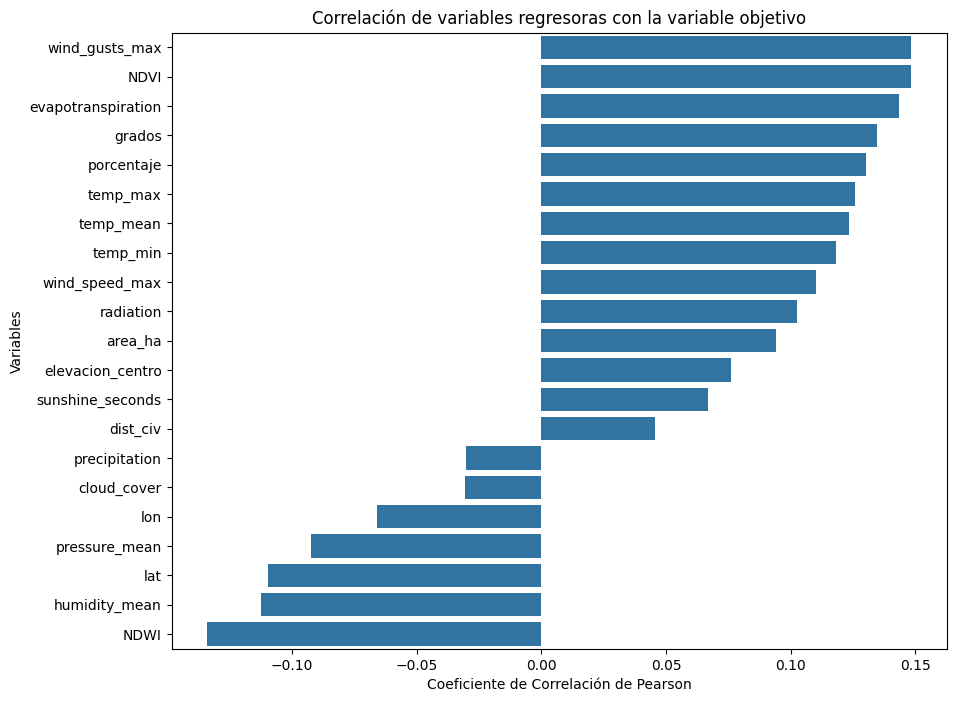

In [26]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

**Conclusión:**

Se observa que las variables más correlacionadas con la variable objetivo son wind_gusts_max, evapotranspiration, grados, porcentaje, NDVI, las variables de temperatura, y NDWI y humidity_mean, con correlación negativa. 

Aún así, las correlaciones son bajas, puesto que ninguna representa un correlación mayor que 0.15. Esto es un indicio de que no existe relación lineal entre la variable objetivo y las variables regresoras. Podría ser problemático plantear un modelo de regresión lineal, puesto que este no conseguiría capturar realmente patrones. 

Por ejemplo, el posible que la temperatura no afecte al FRP de forma lineal, sino que a partir de ciertos grados el riesgo se dispare exponencialmente. O incluso que una variable por sí sola no influya directamente en el frp, sino que esta influencia se vea incrementada con la interacción con otras variables.